In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [ ]:
# Provide Full path as the data and notebook is in a different directory
from pathlib import Path
path = Path(r'H:\MLOps\CustomerChurn-ML\data\raw\data.csv')
df = pd.read_csv(path)
df.shape

(243787, 21)

In [3]:
df.head(1)

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0


In [4]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [5]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [6]:
df.describe(include='all')

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
count,243787.000000,243787.000000,243787.000000,243787,243787,243787,243787,243787,243787,243787.000000,243787.000000,243787.000000,243787,243787.000000,243787.000000,243787,243787.000000,243787,243787,243787,243787.000000
unique,NaN,NaN,NaN,3,4,2,3,2,4,NaN,NaN,NaN,5,NaN,NaN,2,NaN,2,2,243787,NaN
top,NaN,NaN,NaN,Standard,Electronic check,No,Both,No,Computer,NaN,NaN,NaN,Comedy,NaN,NaN,Female,NaN,Yes,Yes,CB6SXPNVZA,NaN
freq,NaN,NaN,NaN,81920,61313,121980,81737,122035,61147,NaN,NaN,NaN,49060,NaN,NaN,121930,NaN,122085,122180,1,NaN
mean,60.083758,12.490695,750.741017,NaN,NaN,NaN,NaN,NaN,NaN,20.502179,92.264061,24.503513,NaN,3.002713,4.504186,NaN,12.018508,NaN,NaN,NaN,0.181232
std,34.285143,4.327615,523.073273,NaN,NaN,NaN,NaN,NaN,NaN,11.243753,50.505243,14.421174,NaN,1.155259,2.872548,NaN,7.193034,NaN,NaN,NaN,0.385211
min,1.000000,4.990062,4.991154,NaN,NaN,NaN,NaN,NaN,NaN,1.000065,5.000547,0.000000,NaN,1.000007,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000
25%,30.000000,8.738543,329.147027,NaN,NaN,NaN,NaN,NaN,NaN,10.763953,48.382395,12.000000,NaN,2.000853,2.000000,NaN,6.000000,NaN,NaN,NaN,0.000000
50%,60.000000,12.495555,649.878487,NaN,NaN,NaN,NaN,NaN,NaN,20.523116,92.249992,24.000000,NaN,3.002261,4.000000,NaN,12.000000,NaN,NaN,NaN,0.000000
75%,90.000000,16.238160,1089.317362,NaN,NaN,NaN,NaN,NaN,NaN,30.219396,135.908048,37.000000,NaN,4.002157,7.000000,NaN,18.000000,NaN,NaN,NaN,0.000000


- from the describe method, we have identified `paperlessbilling`,`MultideviceAccess`,`Gender`,`Subtitles`,`Parental Control` with binary option which we can replace with 0 and 1
- the rest we can have have one-hot encoding
- also will drop `customerID`

In [7]:
# Binary Encoding
binary_col = ['PaperlessBilling','MultiDeviceAccess','Gender','ParentalControl','SubtitlesEnabled']
# Map Yes/No and Male/Female to 1/0
df[binary_col] = df[binary_col].replace(
    {
        'Yes'  : 1, 'No'      : 0,
        'Male' : 1, 'Female' : 0
    }
)

C:\Users\himan\AppData\Local\Temp\ipykernel_19996\3945504313.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_col] = df[binary_col].replace(


In [8]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,0,Both,0,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,1,3,0,0,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,1,Movies,0,Tablet,32.450568,25.725595,18,Action,3.478632,8,1,23,0,1,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,1,Movies,0,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,1,1,1,1,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,0,TV Shows,0,Tablet,27.960389,131.537507,30,Drama,4.276013,2,1,24,1,1,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,1,TV Shows,0,TV,20.083397,45.356653,20,Comedy,3.616170,4,0,0,0,0,4LGYPK7VOL,0


In [9]:
# One-hot Encoding
cat_colums = [col for col in df.columns
              if col not in binary_col and df[col].dtype in ['object','category']]

In [10]:
cat_colums.remove('CustomerID')

In [11]:
cat_colums

['SubscriptionType',
 'PaymentMethod',
 'ContentType',
 'DeviceRegistered',
 'GenrePreference']

In [12]:
# one hot encode
df = pd.get_dummies(df,columns=cat_colums,drop_first=True)

In [13]:
df.head()

,AccountAge,MonthlyCharges,TotalCharges,PaperlessBilling,MultiDeviceAccess,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,SubscriptionType_Premium,SubscriptionType_Standard,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,ContentType_Movies,ContentType_TV Shows,DeviceRegistered_Mobile,DeviceRegistered_TV,DeviceRegistered_Tablet,GenrePreference_Comedy,GenrePreference_Drama,GenrePreference_Fantasy,GenrePreference_Sci-Fi
0,20,11.055215,221.104302,0,0,36.758104,63.531377,10,2.176498,4,1,3,0,0,CB6SXPNVZA,0,True,False,False,False,True,False,False,True,False,False,False,False,False,True
1,57,5.175208,294.986882,1,0,32.450568,25.725595,18,3.478632,8,1,23,0,1,S7R2G87O09,0,False,False,True,False,False,True,False,False,False,True,False,False,False,False
2,73,12.106657,883.785952,1,0,7.395160,57.364061,23,4.238824,6,1,1,1,1,EASDC20BDT,0,False,False,False,False,True,True,False,False,False,False,False,False,True,False
3,32,7.263743,232.439774,0,0,27.960389,131.537507,30,4.276013,2,1,24,1,1,NPF69NT69N,0,False,False,False,True,False,False,True,False,False,True,False,True,False,False
4,57,16.953078,966.325422,1,0,20.083397,45.356653,20,3.616170,4,0,0,0,0,4LGYPK7VOL,0,True,False,False,True,False,False,True,False,True,False,True,False,False,False


In [14]:
# Cleaning
value_col = ['TotalCharges','MonthlyCharges','ViewingHoursPerWeek','AverageViewingDuration']
for col in value_col:
    df[col] = pd.to_numeric(df[col],errors='coerce')


In [15]:
pd.options.mode.copy_on_write = True
# Now .drop() will be 100x+ faster
df = df.drop(columns=["CustomerID"])

In [16]:
# Convert True/False to 1/0
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   AccountAge                      243787 non-null  int64  
 1   MonthlyCharges                  243787 non-null  float64
 2   TotalCharges                    243787 non-null  float64
 3   PaperlessBilling                243787 non-null  int64  
 4   MultiDeviceAccess               243787 non-null  int64  
 5   ViewingHoursPerWeek             243787 non-null  float64
 6   AverageViewingDuration          243787 non-null  float64
 7   ContentDownloadsPerMonth        243787 non-null  int64  
 8   UserRating                      243787 non-null  float64
 9   SupportTicketsPerMonth          243787 non-null  int64  
 10  Gender                          243787 non-null  int64  
 11  WatchlistSize                   243787 non-null  int64  
 12  ParentalControl 

In [18]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                             1.000000
MonthlyCharges                    0.100473
SupportTicketsPerMonth            0.084064
UserRating                        0.022124
WatchlistSize                     0.021739
PaymentMethod_Electronic check    0.016913
GenrePreference_Comedy            0.015876
PaymentMethod_Mailed check        0.014441
GenrePreference_Sci-Fi            0.013183
Gender                            0.007467
SubscriptionType_Standard         0.005692
DeviceRegistered_Mobile           0.001708
DeviceRegistered_Tablet           0.001374
PaperlessBilling                 -0.000923
MultiDeviceAccess                -0.001285
DeviceRegistered_TV              -0.003267
GenrePreference_Drama            -0.003274
ParentalControl                  -0.005531
GenrePreference_Fantasy          -0.005853
ContentType_Movies               -0.006345
ContentType_TV Shows             -0.007029
SubtitlesEnabled                 -0.012372
PaymentMethod_Credit card        -0.028441
Subscriptio

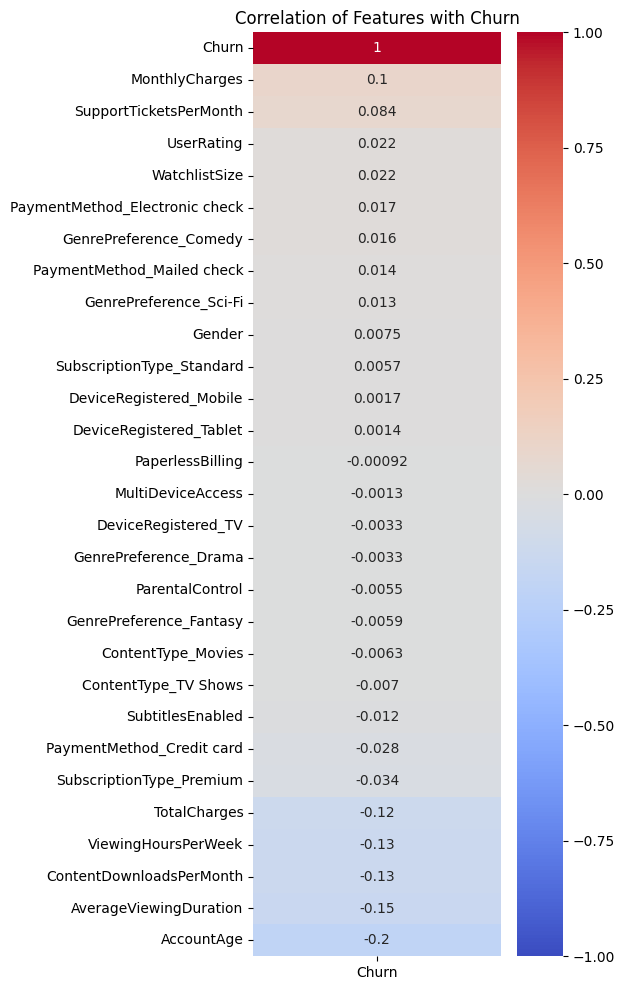

In [19]:
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sb.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

- Positive (higher value => More Likely to Churn)
    - MonthlyCharges (+0.1)
    - SupportsTicketPerMonth (+0.08)

# ML Cleaning and Setup

In [20]:
counts = df['Churn'].value_counts()

In [21]:
print(f"Class Imbalance: {(counts[1] / (counts[0] + counts[1]))*100:.2f}%")

Class Imbalance: 18.12%


In churn prediction, recall (and metrics derived from it, like F1) is usually the most important — here’s why:

1️⃣ Business context Churn prediction is asymmetric in cost:

False Negative (FN): You predict a customer will not churn, but they actually leave → you miss the chance to intervene and keep them.

False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

In [22]:
# Prepare the Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as gb
from sklearn.metrics import classification_report
import time


In [23]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [24]:
X.head()

,AccountAge,MonthlyCharges,TotalCharges,PaperlessBilling,MultiDeviceAccess,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,SubscriptionType_Premium,SubscriptionType_Standard,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,ContentType_Movies,ContentType_TV Shows,DeviceRegistered_Mobile,DeviceRegistered_TV,DeviceRegistered_Tablet,GenrePreference_Comedy,GenrePreference_Drama,GenrePreference_Fantasy,GenrePreference_Sci-Fi
0,20,11.055215,221.104302,0,0,36.758104,63.531377,10,2.176498,4,1,3,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1
1,57,5.175208,294.986882,1,0,32.450568,25.725595,18,3.478632,8,1,23,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0
2,73,12.106657,883.785952,1,0,7.395160,57.364061,23,4.238824,6,1,1,1,1,0,0,0,0,1,1,0,0,0,0,0,0,1,0
3,32,7.263743,232.439774,0,0,27.960389,131.537507,30,4.276013,2,1,24,1,1,0,0,0,1,0,0,1,0,0,1,0,1,0,0
4,57,16.953078,966.325422,1,0,20.083397,45.356653,20,3.616170,4,0,0,0,0,1,0,0,1,0,0,1,0,1,0,1,0,0,0


In [25]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

In [26]:
# Train Test Split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=21)
# We use stratify = y, because that will proportionalty split the imbalanced class in the train and test, because its only 18% overall
threshold = 0.3 # lower than 0.5 to boost recall (see next to choose the right value)

### Random Forest Classifier

In [27]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=21,
    n_jobs=-1
)

rf.fit(X_train,y_train)
proba = rf.predict_proba(X_test)[:,1]
y_pred = (proba >= threshold).astype(int)

print(classification_report(y_test,y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.862     0.886     0.874     39921
           1      0.412     0.359     0.384      8837

    accuracy                          0.791     48758
   macro avg      0.637     0.623     0.629     48758
weighted avg      0.780     0.791     0.785     48758



In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.367   0.491   0.420   
0.3     0.412   0.359   0.384   
0.35    0.456   0.246   0.320   
0.4     0.501   0.159   0.241   
0.45    0.550   0.098   0.166   
0.5     0.590   0.055   0.101   


- For `threshold` of `0.3`, we are catching 35.9% percent of the churners with RandomForest
- This results is not good

### LightGBM Classifier

In [29]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= threshold).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35345, number of negative: 159684
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035474 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1518
[LightGBM] [Info] Number of data points in the train set: 195029, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
⏱ Training time: 12.26 seconds
⏱ Prediction time: 0.5819 seconds
              precision    recall  f1-score   support

           0      0.942     0.385     0.547     39921
           1      0.243     0.893     0.382      8837

    accuracy                          0.477     48758
   macro avg      0.593     0.639     0.464     48758
weighted avg      0.815     0.477     0.517     48758



- LightGBM achieves a good score in recall (89%) but the accuracy is low (24%), meaning we might flag some non-churner's chuner - however, if the retention package is good we can go with that. 
- However, the accuracy is still low.

In [30]:
print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.227   0.930   0.365   
0.3     0.243   0.893   0.382   
0.35    0.260   0.850   0.399   
0.4     0.279   0.797   0.413   
0.45    0.298   0.738   0.424   
0.5     0.316   0.666   0.429   


### XGBoost Classifier

In [31]:
from xgboost import XGBClassifier


In [32]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [33]:
print(scale_pos_weight)

4.517866742113453


In [35]:
xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth=6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    n_jobs = -1,
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'logloss'
)

start_train = time.time()
xgb.fit(X_train,y_train)
train_time = time.time() - start_train
print(f"Training Time : {train_time:.2f}s")

predict_time = time.time()
proba_xgb = xgb.predict_proba(X_test)[:,1]
y_pred = (proba_xgb >= threshold).astype(int)
pred_time2 = time.time() - predict_time
print(f"Prediction Time: {pred_time2:.2f}s")

print(classification_report(y_test,y_pred,digits=3))



Training Time : 12.87s
Prediction Time: 0.18s
              precision    recall  f1-score   support

           0      0.941     0.395     0.556     39921
           1      0.245     0.888     0.384      8837

    accuracy                          0.484     48758
   macro avg      0.593     0.641     0.470     48758
weighted avg      0.815     0.484     0.525     48758



In [37]:
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba_xgb >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.229   0.927   0.368   
0.3     0.245   0.888   0.384   
0.35    0.262   0.842   0.399   
0.4     0.280   0.787   0.413   
0.45    0.298   0.724   0.423   
0.5     0.320   0.657   0.430   


### Results from the testing different models
1. RandomForestClassifier
    * Recall   : 36%
    * Accuracy : 41%

2. LightGBM
    * Recall    : 89%
    * Accuracy  : 24%

3. XGBoost
    * Recall     : 88%
    * Accuracy   : 24%

- Based from the above results, both the LightGBM and XGBoost perform well on recall but not on accuracy.
- Prediction time for XGBoost is much faster as compared to LightGBM, so I decided to go with `XGBoost`

### Hyperparemeter Tuning (Optuna)

In [38]:
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    xgb_new = XGBClassifier(**params)
    xgb_new.fit(X_train,y_train)
    probs = xgb_new.predict_proba(X_test)[:,1]
    y_pred_new = (probs >= threshold).astype(int)
    return recall_score(y_test,y_pred_new,pos_label=1)


    

h:\MLOps\CustomerChurn-ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
# Run Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=30)
print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-04-08 19:01:01,407] A new study created in memory with name: no-name-a088f0b9-15a1-41b5-bc3d-03854ba317d7
[I 2026-04-08 19:01:13,263] Trial 0 finished with value: 0.8690732148919317 and parameters: {'n_estimators': 408, 'learning_rate': 0.1262489193168966, 'max_depth': 7, 'subsample': 0.6805623419226461, 'colsample_bytree': 0.530126440771167, 'min_child_weight': 9, 'gamma': 4.5768132656987, 'reg_alpha': 3.482543165799995, 'reg_lambda': 3.573029042575647}. Best is trial 0 with value: 0.8690732148919317.
[I 2026-04-08 19:01:30,295] Trial 1 finished with value: 0.8660178793708272 and parameters: {'n_estimators': 656, 'learning_rate': 0.06326747863484934, 'max_depth': 8, 'subsample': 0.8234286796174776, 'colsample_bytree': 0.7174022123493791, 'min_child_weight': 2, 'gamma': 4.427715188521304, 'reg_alpha': 1.1094994421532856, 'reg_lambda': 2.587045675649801}. Best is trial 0 with value: 0.8690732148919317.
[I 2026-04-08 19:01:39,534] Trial 2 finished with value: 0.9035871902229263 a

Best Params: {'n_estimators': 495, 'learning_rate': 0.010999606828509369, 'max_depth': 4, 'subsample': 0.952519072276336, 'colsample_bytree': 0.9452623360059503, 'min_child_weight': 9, 'gamma': 2.4743981409009015, 'reg_alpha': 2.2606223534323435, 'reg_lambda': 4.979188454928984}
Best Recall: 0.933687903134548


In [40]:
print(scale_pos_weight)

4.517866742113453


In [41]:
best_params = study.best_params
best_params.update(
    {
        "random_state" : 42,
        "n_jobs" : -1,
        "scale_pos_weight" : scale_pos_weight,
        "eval_metric" : "logloss"
    }
)

# Create the model from Best Parameters
XGB = XGBClassifier(**best_params)

# Training
starter = time.time()
XGB.fit(X_train,y_train)
end = time.time() - starter
print(f"Training Time: {end:.2f}%")

# Prediction
starter2 = time.time()
probs_final = XGB.predict_proba(X_test)[:,1]
pred_final = (probs_final >= threshold).astype(int)
end2 = time.time() - starter2
print(f"Prediction Time : {end2:.2f}%")

print(classification_report(y_test, pred_final, digits=3))

Training Time: 11.40%
Prediction Time : 0.14%
              precision    recall  f1-score   support

           0      0.953     0.300     0.457     39921
           1      0.228     0.934     0.367      8837

    accuracy                          0.415     48758
   macro avg      0.591     0.617     0.412     48758
weighted avg      0.822     0.415     0.440     48758



In [42]:
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (probs_final >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Thresh  Prec_1  Rec_1   F1_1    
0.25    0.212   0.963   0.347   
0.3     0.228   0.934   0.367   
0.35    0.246   0.893   0.385   
0.4     0.266   0.837   0.404   
0.45    0.288   0.768   0.419   
0.5     0.314   0.690   0.431   


# Final Result
1. Recall : 93% - Good
2. Precision : 22% - Lowest so far (Many loyal customers will be getting flagged)

# Interpretation:
* This model is actually catching almost all the churners, however, this also means that there is an aggressive retention campaign and cost for contacting non-churners is low
* Low precision also means that more than 75% of the people you target wont' actually churn